## How to Run This Notebook

1. Click Runtime → Run all
2. The dataset will download automatically from Google Drive
3. No setup required

Notes:
- Uses Google Drive link for dataset
- No Kaggle API needed

In [ ]:
!pip install -q gdown

import os
import gdown
import pandas as pd

file_id = "18wOqQKCiVR0bVZqO7vtobN9TCypcjvq-"
csv_name = "/content/credit_card_fraud_dataset.csv"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Function to check if file looks valid
def file_is_valid(path):
    if not os.path.exists(path):
        return False
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            first_line = f.readline()
        return "TransactionID" in first_line
    except:
        return False

# Download only if needed or invalid
if not file_is_valid(csv_name):
    if os.path.exists(csv_name):
        os.remove(csv_name)
        print("Removed invalid file")
    gdown.download(url, csv_name, quiet=False)
    print("Downloaded dataset")
else:
    print("Using existing valid dataset")

# Load data
df = pd.read_csv(csv_name)

print("Shape:", df.shape)
df.head()

Downloading...
From: https://drive.google.com/uc?export=download&id=18wOqQKCiVR0bVZqO7vtobN9TCypcjvq-
To: /content/credit_card_fraud_dataset.csv
100%|██████████| 6.41M/6.41M [00:00<00:00, 33.3MB/s]


Downloaded dataset
Shape: (100000, 7)


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [ ]:
df.tail()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0
99999,100000,2024-03-05 19:41:36.027606,1596.79,675,refund,Houston,0


In [ ]:
df.sample(10)

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
42232,42233,2024-02-26 06:11:35.700760,1121.89,231,refund,San Antonio,0
42147,42148,2024-01-09 09:17:35.700211,1967.12,991,refund,San Jose,0
68825,68826,2024-05-15 09:15:35.871296,3369.69,751,refund,San Diego,0
33826,33827,2024-04-13 14:40:35.632617,116.61,64,refund,Los Angeles,0
891,892,2024-07-05 23:00:35.467034,4831.16,880,purchase,Philadelphia,0
31002,31003,2024-07-19 08:26:35.614222,4889.79,561,refund,Los Angeles,0
83429,83430,2023-11-13 18:40:35.951819,1826.37,703,refund,New York,1
58413,58414,2024-09-29 16:06:35.822216,1945.45,19,refund,Los Angeles,0
5390,5391,2024-06-10 19:28:35.495799,389.09,455,refund,Dallas,0
57022,57023,2024-06-29 00:22:35.812301,606.86,257,refund,Chicago,0


In [ ]:
df.columns

Index(['TransactionID', 'TransactionDate', 'Amount', 'MerchantID',
       'TransactionType', 'Location', 'IsFraud'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [ ]:
df.isnull().sum()

,0
TransactionID,0
TransactionDate,0
Amount,0
MerchantID,0
TransactionType,0
Location,0
IsFraud,0


In [ ]:
df.describe()

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [ ]:
df.nunique()

,0
TransactionID,100000
TransactionDate,100000
Amount,90621
MerchantID,1000
TransactionType,2
Location,10
IsFraud,2


In [ ]:
df.corr(numeric_only=True)

,TransactionID,Amount,MerchantID,IsFraud
TransactionID,1.000000,0.001972,-0.003623,-0.000209
Amount,0.001972,1.000000,-0.000386,0.001399
MerchantID,-0.003623,-0.000386,1.000000,0.001157
IsFraud,-0.000209,0.001399,0.001157,1.000000


In [ ]:
df['IsFraud'].value_counts()

,count
IsFraud,
0,99000
1,1000


array([[<Axes: title={'center': 'TransactionID'}>,
        <Axes: title={'center': 'Amount'}>],
       [<Axes: title={'center': 'MerchantID'}>,
        <Axes: title={'center': 'IsFraud'}>]], dtype=object)

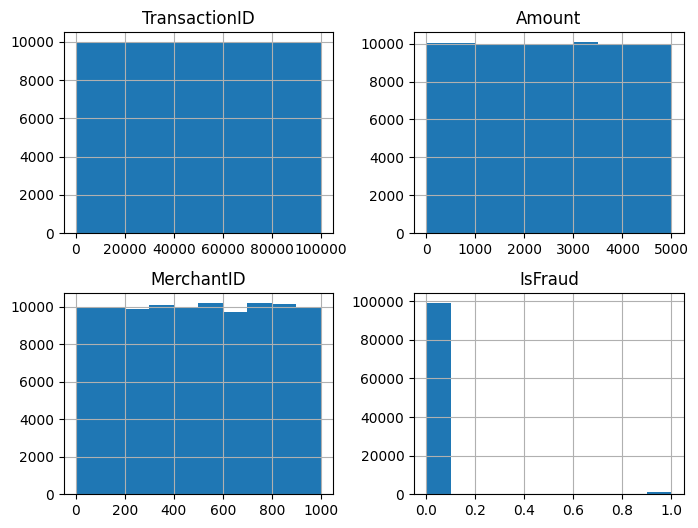

In [ ]:
df.hist(figsize=(8,6))


In [ ]:
corr = df.select_dtypes(include='number').corr()

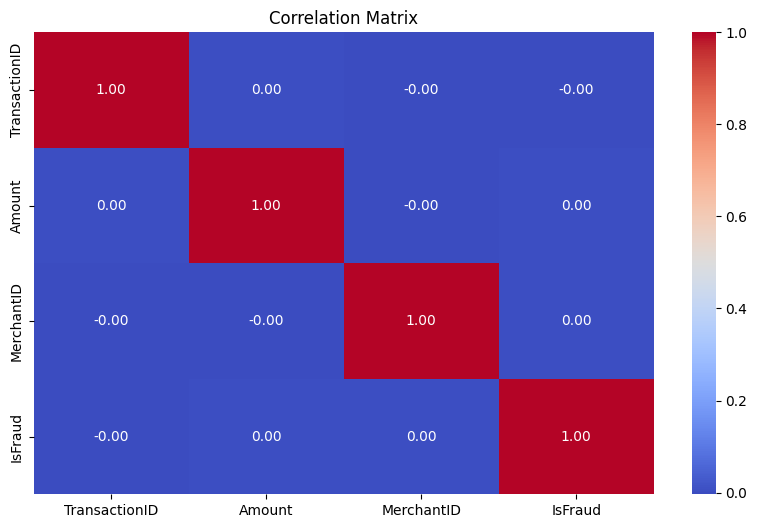

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

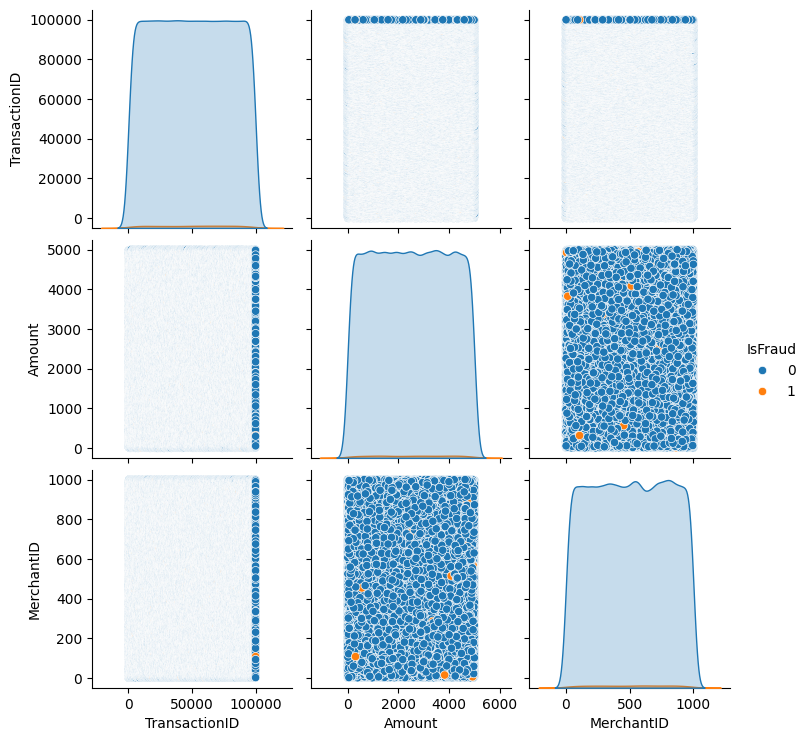

In [ ]:
sns.pairplot(df,hue='IsFraud')

<Axes: ylabel='count'>

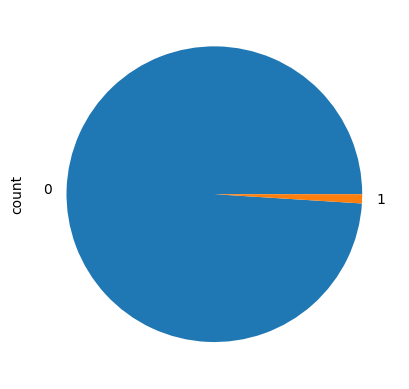

In [ ]:
df['IsFraud'].value_counts().plot(kind='pie')

In [ ]:
round((df['IsFraud'].value_counts().get(1, 0) / df.shape[0]) * 100, 2)

np.float64(1.0)

In [ ]:
df['Amount'].describe().astype(int)

,Amount
count,100000
mean,2497
std,1442
min,1
25%,1247
50%,2496
75%,3743
max,4999


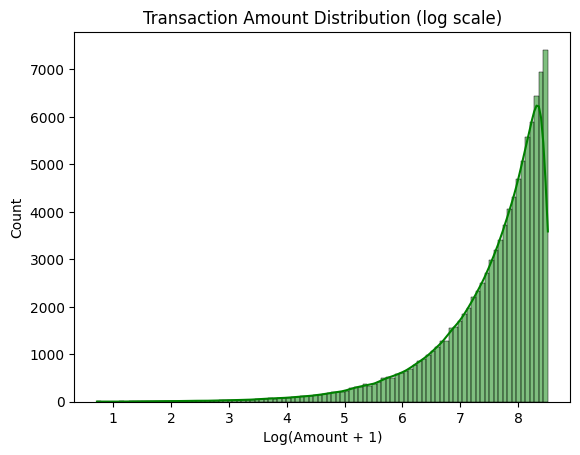

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.histplot(np.log1p(df['Amount']), bins=100, kde=True, color='green')
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Log(Amount + 1)')
plt.show()

In [ ]:
df.corr(numeric_only=True)['IsFraud'].sort_values(ascending=False)

,IsFraud
IsFraud,1.000000
Amount,0.001399
MerchantID,0.001157
TransactionID,-0.000209


In [ ]:
df.groupby('TransactionType')['IsFraud'].mean().sort_values(ascending=False)

,IsFraud
TransactionType,
refund,0.010114
purchase,0.009886


In [ ]:
df.groupby('Location')['IsFraud'].mean().sort_values(ascending=False)

,IsFraud
Location,
New York,0.011608
San Diego,0.011374
Houston,0.010509
Phoenix,0.009940
San Antonio,0.009839
Dallas,0.009825
Los Angeles,0.009561
Chicago,0.009320
Philadelphia,0.009116


In [ ]:
df.groupby('MerchantID')['IsFraud'].mean().sort_values(ascending=False).head(10)

,IsFraud
MerchantID,
640,0.058140
156,0.048544
583,0.047170
659,0.045455
939,0.043956
436,0.041667
568,0.041237
968,0.041096
401,0.040816


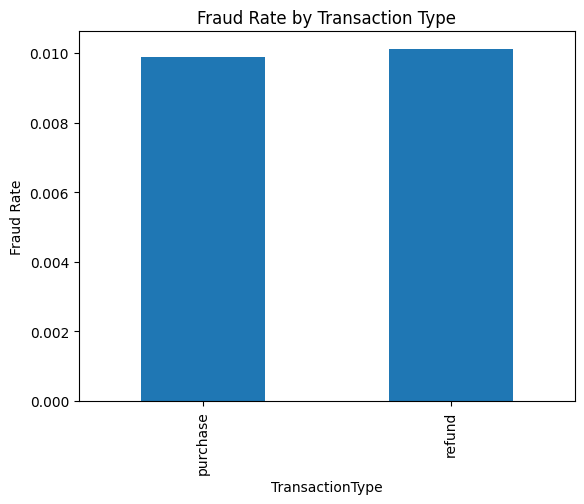

In [ ]:
df.groupby('TransactionType')['IsFraud'].mean().plot(kind='bar', title='Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

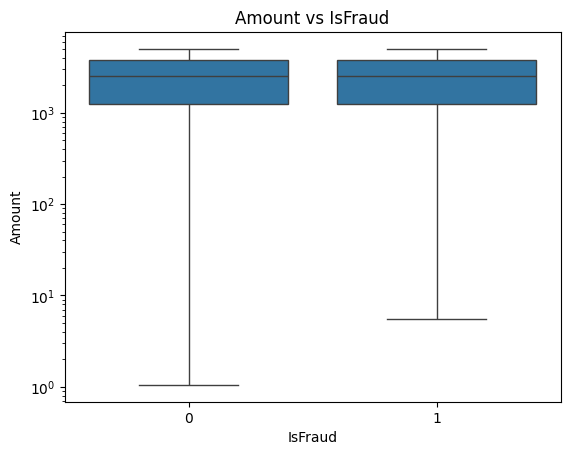

In [ ]:
# Boxplot
sns.boxplot(data=df, x='IsFraud', y='Amount')
plt.title('Amount vs IsFraud')
plt.yscale('log')  # helpful if amounts are skewed
plt.show()

The boxplot shows that the distribution of transaction amounts for fraud and non-fraud cases is very similar. The medians and spread are almost the same, which suggests that **transaction amount alone is not a strong indicator of fraud.**

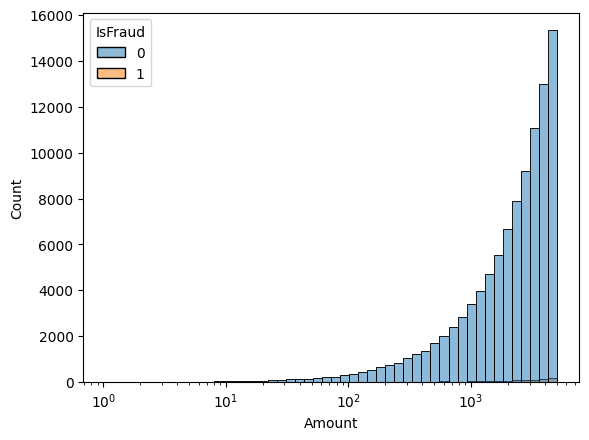

In [ ]:
# Histogram
sns.histplot(data=df, x='Amount', hue='IsFraud', bins=50, log_scale=True)
plt.show()

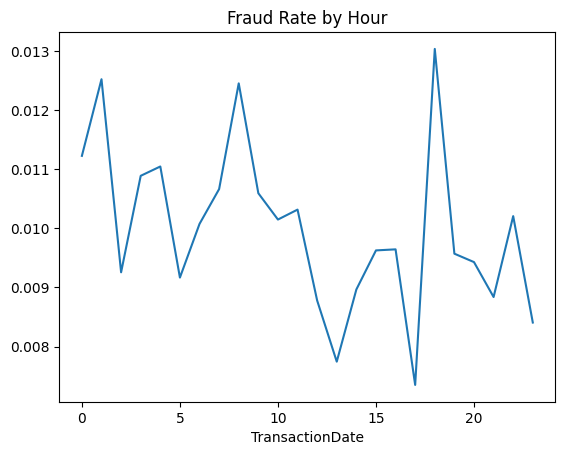

In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df.groupby(df['TransactionDate'].dt.hour)['IsFraud'].mean().plot()
plt.title('Fraud Rate by Hour')
plt.show()

In [ ]:
df.columns

Index(['TransactionID', 'TransactionDate', 'Amount', 'MerchantID',
       'TransactionType', 'Location', 'IsFraud'],
      dtype='object')

In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['Day'] = df['TransactionDate'].dt.day
df['Hour'] = df['TransactionDate'].dt.hour

df = df.drop('TransactionDate', axis=1)

XGBoost cannot use raw datetime. Convert data and extract features. This helps the model understand patterns like “fraud happens more at night”. Then remove the original date coiumn.

In [ ]:
df = pd.get_dummies(df, columns=['TransactionType', 'Location'], drop_first=True)

Columns like TransactionType and Location are text, and machine learning models cannot understand text. So I convert them into numbers using one-hot encoding. Now the model can use these features.

In [ ]:
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

In [ ]:
df.columns

Index(['TransactionID', 'Amount', 'MerchantID', 'IsFraud', 'Year', 'Month',
       'Day', 'Hour', 'TransactionType_refund', 'Location_Dallas',
       'Location_Houston', 'Location_Los Angeles', 'Location_New York',
       'Location_Philadelphia', 'Location_Phoenix', 'Location_San Antonio',
       'Location_San Diego', 'Location_San Jose'],
      dtype='object')

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def show_confusion_details(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  TN, FP, FN, TP = cm.ravel()

  print("Confusion Matrix:")
  print(cm)
  print("\nDetailed Breakdown:")
  print(f"True Negatives (TN): {TN}")
  print(f"False Positives (FP): {FP}")
  print(f"False Negatives (FN): {FN}")
  print(f"True Positives (TP): {TP}")

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

print("Train distribution:")
print(y_train.value_counts())
print()
print("Validation distribution:")
print(y_val.value_counts())
print()
print("Test distribution:")
print(y_test.value_counts())


Train distribution:
IsFraud
0    59400
1      600
Name: count, dtype: int64

Validation distribution:
IsFraud
0    19800
1      200
Name: count, dtype: int64

Test distribution:
IsFraud
0    19800
1      200
Name: count, dtype: int64


In [ ]:
## Create Balanced Training Data (SMOTE on training split only)
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Convert categorical columns BEFORE SMOTE
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

print("Original training distribution:")
print(y_train.value_counts())

# 2. Apply SMOTE on numeric data only
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

print("\nTraining distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training distribution:
IsFraud
0    59400
1      600
Name: count, dtype: int64

Training distribution after SMOTE:
IsFraud
0    59400
1    59400
Name: count, dtype: int64


In [ ]:
## Train XGBoost on SMOTE-Balanced Training Data
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Encode all splits the same way
X_train_enc = pd.get_dummies(X_train)
X_val_enc = pd.get_dummies(X_val)
X_test_enc = pd.get_dummies(X_test)

# Align columns
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# SMOTE only on training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Ensure validation data is preprocessed properly
X_val_enc = pd.get_dummies(X_val)
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Create predictions
y_val_pred = model.predict(X_val_enc)
y_val_prob = model.predict_proba(X_val_enc)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
TN, FP, FN, TP = cm.ravel()

print("Validation Confusion Matrix:")
print(cm)
print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, zero_division=0))

print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Validation Confusion Matrix:
[[19439   361]
 [  195     5]]
TN: 19439, FP: 361, FN: 195, TP: 5

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19800
           1       0.01      0.03      0.02       200

    accuracy                           0.97     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.97      0.98     20000

Validation ROC-AUC: 0.5006007575757575


In [ ]:
## Tune threshold on the validation set
for t in [0.1, 0.2, 0.3, 0.5, 0.7]:
    y_pred = (y_val_prob > t).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    TN, FP, FN, TP = cm.ravel()

    print()
    print("Validation Confusion Matrix for XGBoost with SMOTE:")
    print(cm)

    print()
    print(f"Threshold: {t}")
    print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, zero_division=0))
    print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_prob))



Validation Confusion Matrix for XGBoost with SMOTE:
[[15127  4673]
 [  147    53]]

Threshold: 0.1
TN: 15127, FP: 4673, FN: 147, TP: 53

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19800
           1       0.01      0.03      0.02       200

    accuracy                           0.97     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.97      0.98     20000

Validation ROC-AUC: 0.5006007575757575

Validation Confusion Matrix for XGBoost with SMOTE:
[[17453  2347]
 [  169    31]]

Threshold: 0.2
TN: 17453, FP: 2347, FN: 169, TP: 31

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19800
           1       0.01      0.03      0.02       200

    accuracy                           0.97     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.97      0

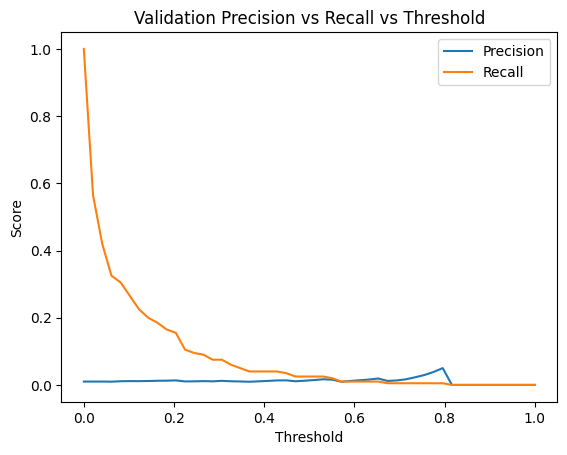

In [ ]:
## Plot Precision vs Recall vs Threshold on validation data
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.linspace(0, 1, 50)
precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_val_prob > t).astype(int)
    precisions.append(precision_score(y_val, y_pred, zero_division=0))
    recalls.append(recall_score(y_val, y_pred, zero_division=0))

plt.figure()
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Precision vs Recall vs Threshold")
plt.legend()
plt.show()

## Result:-
This XGBoost model is trained on the SMOTE-balanced training split, threshold tuning is done on the original validation split, and the test set stays untouched until the final evaluation. That lets you compare models fairly without leaking information from the test set back into model selection.

In [ ]:
## Create Balanced Training Data (Downsampling)
import pandas as pd

# Combine training data
train_df = pd.concat([X_train, y_train], axis=1)

# Separate classes
fraud = train_df[train_df['IsFraud'] == 1]
non_fraud = train_df[train_df['IsFraud'] == 0]

# Downsample non-fraud to match fraud count
non_fraud_downsampled = non_fraud.sample(n=len(fraud), random_state=42)

# Combine to create balanced dataset
balanced_train = pd.concat([fraud, non_fraud_downsampled])

# Shuffle
balanced_train = balanced_train.sample(frac=1, random_state=42)

# Split again into X and y
X_train_bal = balanced_train.drop('IsFraud', axis=1)
y_train_bal = balanced_train['IsFraud']

print(y_train_bal.value_counts())

IsFraud
0    600
1    600
Name: count, dtype: int64


In [ ]:
## Train Model on Balanced Data
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_enc, y_train)

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_bal, y_train_bal)

model.fit(X_train_bal, y_train_bal)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Encode test data
X_test_enc = pd.get_dummies(X_test)

# Align columns with training data
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Predict
y_test_pred = model.predict(X_test_enc)

In [ ]:
## Show Confusion Matrix Grid
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:\n", cm)
print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

Confusion Matrix:
 [[19416   384]
 [  197     3]]
TN: 19416, FP: 384, FN: 197, TP: 3


Confusion Matrix for XGBoost with Downsampling:
[[15180  4620]
 [  145    55]]


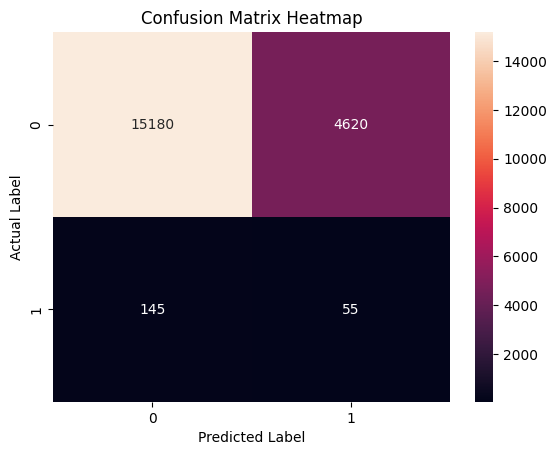


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.77      0.86     19800
           1       0.01      0.28      0.02       200

    accuracy                           0.76     20000
   macro avg       0.50      0.52      0.44     20000
weighted avg       0.98      0.76      0.86     20000

ROC-AUC: 0.5102085858585859


In [ ]:
## Evaluate
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Encode test data (same preprocessing as training)
X_test_enc = pd.get_dummies(X_test)

# Align columns with training data
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Predict probabilities
y_prob = model.predict_proba(X_test_enc)[:, 1]

# Use tuned threshold (better for fraud detection than default 0.5)
best_threshold = 0.1
y_test_pred = (y_prob > best_threshold).astype(int)

# Evaluation
print("Confusion Matrix for XGBoost with Downsampling:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Heatmap Visualization
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


In [ ]:
# Tune threshold
from sklearn.metrics import confusion_matrix

# Encode test data (same preprocessing as training)
X_test_enc = pd.get_dummies(X_test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Predict probabilities
y_prob = model.predict_proba(X_test_enc)[:, 1]

# Try multiple thresholds
for t in [0.1, 0.2, 0.3, 0.5, 0.7]:
    y_pred = (y_prob > t).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    print(f"\nThreshold: {t}")
    print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")



Threshold: 0.1
TN: 15180, FP: 4620, FN: 145, TP: 55

Threshold: 0.2
TN: 17409, FP: 2391, FN: 175, TP: 25

Threshold: 0.3
TN: 18507, FP: 1293, FN: 187, TP: 13

Threshold: 0.5
TN: 19416, FP: 384, FN: 197, TP: 3

Threshold: 0.7
TN: 19733, FP: 67, FN: 200, TP: 0


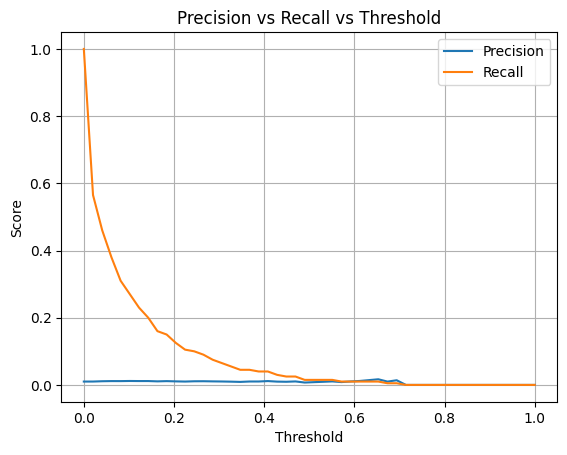

In [ ]:
# Plot Precision vs Recall vs Threshold
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Ensure correct preprocessing
X_test_enc = pd.get_dummies(X_test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Probabilities
y_prob = model.predict_proba(X_test_enc)[:, 1]

thresholds = np.linspace(0, 1, 50)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)

    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))

plt.figure()
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Pick Best Threshold
from sklearn.metrics import f1_score
import numpy as np

f1_scores = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1 Score:", f1_scores[best_idx])

Best Threshold: 0.1020408163265306
Precision: 0.01172129368352507
Recall: 0.27
F1 Score: 0.02246723528188059


## Result:-
After downsamping technique the dataset, the model got better at finding fraud cases. But it also started marking many normal transactions as fraud, so precision became very low (around 1%). This shows that when we try to catch more fraud, we may also get more false alarms.

In [ ]:
## Final Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Final prediction using best threshold
y_final = (y_prob > best_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_final)
TN, FP, FN, TP = cm.ravel()

print("Final Confusion Matrix:\n", cm)
print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

print("\nClassification Report:")
print(classification_report(y_test, y_final, zero_division=0))

Final Confusion Matrix:
 [[15247  4553]
 [  146    54]]
TN: 15247, FP: 4553, FN: 146, TP: 54

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.77      0.87     19800
           1       0.01      0.27      0.02       200

    accuracy                           0.77     20000
   macro avg       0.50      0.52      0.44     20000
weighted avg       0.98      0.77      0.86     20000



# Conclusion

SMOTE and Downsampling were used to handle class imbalance in fraud detection. With SMOTE, the model learned better patterns of fraud by creating synthetic samples, but it slightly increased false positives. With Downsampling, the model became simpler and faster, but some useful information from normal transactions was lost.

In my results, both SMOTE and Downsampling performed almost similarly because the dataset is highly imbalanced. However, the overall model still did not achieve an optimal solution, so further tuning and improvements are needed.

In [ ]:
#####  Craig's additions below  ######

In [ ]:
print(df.columns)

Index(['TransactionID', 'Amount', 'MerchantID', 'IsFraud', 'Year', 'Month',
       'Day', 'Hour', 'TransactionType_refund', 'Location_Dallas',
       'Location_Houston', 'Location_Los Angeles', 'Location_New York',
       'Location_Philadelphia', 'Location_Phoenix', 'Location_San Antonio',
       'Location_San Diego', 'Location_San Jose'],
      dtype='object')


## Logistic Regression
This section reuses the same train, validation, and test splits defined above. SMOTE is applied only to the training data after scaling.

In [ ]:
print("Using shared split sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Using shared split sizes:
Train: (60000, 17) (60000,)
Validation: (20000, 17) (20000,)
Test: (20000, 17) (20000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

smote_log = SMOTE(random_state=42)
X_train_log_smote, y_train_log_smote = smote_log.fit_resample(X_train_scaled, y_train)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_log_smote, y_train_log_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_val_scaled)
y_prob = model.predict_proba(X_val_scaled)[:, 1]

print("Validation confusion matrix:")
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred, zero_division=0))
print("Validation ROC AUC:", roc_auc_score(y_val, y_prob))

Validation confusion matrix:
[[10107  9693]
 [   93   107]]
              precision    recall  f1-score   support

           0       0.99      0.51      0.67     19800
           1       0.01      0.54      0.02       200

    accuracy                           0.51     20000
   macro avg       0.50      0.52      0.35     20000
weighted avg       0.98      0.51      0.67     20000

Validation ROC AUC: 0.5166409090909091


In [ ]:
threshold = 0.2
y_pred_custom = (y_prob > threshold).astype(int)

print(f"Validation confusion matrix at threshold {threshold}:")
print(confusion_matrix(y_val, y_pred_custom))
print(classification_report(y_val, y_pred_custom, zero_division=0))

Validation confusion matrix at threshold 0.2:
[[    0 19800]
 [    0   200]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     19800
           1       0.01      1.00      0.02       200

    accuracy                           0.01     20000
   macro avg       0.01      0.50      0.01     20000
weighted avg       0.00      0.01      0.00     20000



In [ ]:
print("Validation probability stats")
print("Min probability:", y_prob.min())
print("Max probability:", y_prob.max())
print("Mean probability:", y_prob.mean())
print()
print("Top 20 predicted fraud probabilities on validation:")
print(np.sort(y_prob)[-20:])

Validation probability stats
Min probability: 0.35236238942418285
Max probability: 0.6279171815608848
Mean probability: 0.4970059814402577

Top 20 predicted fraud probabilities on validation:
[0.60982519 0.61059104 0.6107245  0.61087585 0.61094804 0.611001
 0.61166694 0.61167054 0.6119567  0.61239781 0.61261994 0.6127899
 0.61301078 0.61675387 0.6181353  0.61837258 0.6196912  0.62189865
 0.6278984  0.62791718]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("Validation fraud precision:", precision_score(y_val, y_pred, zero_division=0))
print("Validation fraud recall:", recall_score(y_val, y_pred, zero_division=0))
print("Validation fraud F1:", f1_score(y_val, y_pred, zero_division=0))
print("Validation ROC AUC:", roc_auc_score(y_val, y_prob))

Validation fraud precision: 0.010918367346938776
Validation fraud recall: 0.535
Validation fraud F1: 0.0214
Validation ROC AUC: 0.5166409090909091


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

threshold_results = []

for t in [0.50, 0.30, 0.20, 0.10]:
    y_pred_t = (y_prob >= t).astype(int)

    threshold_results.append({
        "Threshold": t,
        "Fraud Precision": precision_score(y_val, y_pred_t, zero_division=0),
        "Fraud Recall": recall_score(y_val, y_pred_t, zero_division=0),
        "Fraud F1": f1_score(y_val, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Fraud Precision,Fraud Recall,Fraud F1
0,0.5,0.010918,0.535,0.021400
1,0.3,0.010000,1.000,0.019802
2,0.2,0.010000,1.000,0.019802
3,0.1,0.010000,1.000,0.019802


In [ ]:
chosen_threshold = threshold_df.loc[threshold_df['Fraud F1'].idxmax(), 'Threshold']
y_val_pred_t = (y_prob >= chosen_threshold).astype(int)
y_test_prob_log = model.predict_proba(X_test_scaled)[:, 1]
y_test_pred_log = (y_test_prob_log >= chosen_threshold).astype(int)

print(f"Chosen validation threshold: {chosen_threshold}")
print("Validation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred_t))
print()
print("Final test confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_log))
print(classification_report(y_test, y_test_pred_log, zero_division=0))

Chosen validation threshold: 0.5
Validation confusion matrix:
[[10107  9693]
 [   93   107]]

Final test confusion matrix:
[[10035  9765]
 [  103    97]]
              precision    recall  f1-score   support

           0       0.99      0.51      0.67     19800
           1       0.01      0.48      0.02       200

    accuracy                           0.51     20000
   macro avg       0.50      0.50      0.34     20000
weighted avg       0.98      0.51      0.66     20000



### Logistic Regression Notes

Logistic regression now uses the shared train-validation-test split. Scaling is fit on the training split only, SMOTE is applied only to the scaled training data, the validation set is used for threshold selection, and the test set is used once at the end for final reporting.

# try some work on the features

In [ ]:
# Feature engineering without leakage
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

merchant_fraud_rate = (
    X_train_fe.join(y_train)
    .groupby('MerchantID')['IsFraud']
    .mean()
)

X_train_fe['MerchantFraudRate'] = X_train_fe['MerchantID'].map(merchant_fraud_rate)
X_val_fe['MerchantFraudRate'] = X_val_fe['MerchantID'].map(merchant_fraud_rate).fillna(0)
X_test_fe['MerchantFraudRate'] = X_test_fe['MerchantID'].map(merchant_fraud_rate).fillna(0)

X_train_fe = X_train_fe.drop(columns=['MerchantID'])
X_val_fe = X_val_fe.drop(columns=['MerchantID'])
X_test_fe = X_test_fe.drop(columns=['MerchantID'])

In [ ]:
print(X_train_fe['MerchantFraudRate'].describe())
print()
print("Top risky merchants:")
print(X_train_fe['MerchantFraudRate'].sort_values(ascending=False).head(10))
print()
print("Lowest risk merchants:")
print(X_train_fe['MerchantFraudRate'].sort_values().head(10))

count    60000.000000
mean         0.010000
std          0.012817
min          0.000000
25%          0.000000
50%          0.000000
75%          0.016949
max          0.075000
Name: MerchantFraudRate, dtype: float64

Top risky merchants:
60424    0.075
31130    0.075
35817    0.075
6197     0.075
95892    0.075
42209    0.075
79407    0.075
21900    0.075
28697    0.075
62461    0.075
Name: MerchantFraudRate, dtype: float64

Lowest risk merchants:
90137    0.0
28301    0.0
76817    0.0
98695    0.0
15445    0.0
84042    0.0
44392    0.0
80273    0.0
83352    0.0
18290    0.0
Name: MerchantFraudRate, dtype: float64


A merchant-level fraud rate feature is still useful, but it must be computed from the training split only and then mapped to validation and test data. This version avoids leakage by never using validation or test labels when building the feature.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_val_fe_scaled = scaler_fe.transform(X_val_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

smote_fe = SMOTE(random_state=42)
X_train_fe_smote, y_train_fe_smote = smote_fe.fit_resample(X_train_fe_scaled, y_train)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_fe_smote, y_train_fe_smote)

LogisticRegression(max_iter=1000, random_state=42)

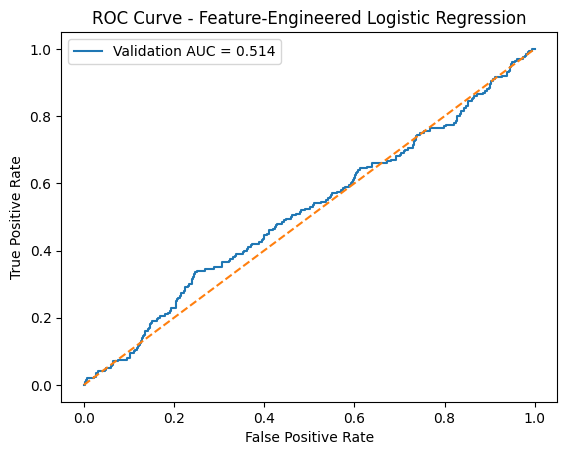

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = log_reg.predict_proba(X_val_fe_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Validation AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Feature-Engineered Logistic Regression")
plt.legend()
plt.show()

In [ ]:
# Random Forest trained on SMOTE-balanced training data
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=623,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_predictions = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_predictions)
print("Random Forest validation accuracy:", rf_accuracy)
print()
print("Validation classification report:")
print(classification_report(y_val, rf_predictions, zero_division=0))

Random Forest validation accuracy: 0.9883

Validation classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.05      0.01      0.02       200

    accuracy                           0.99     20000
   macro avg       0.52      0.50      0.51     20000
weighted avg       0.98      0.99      0.98     20000



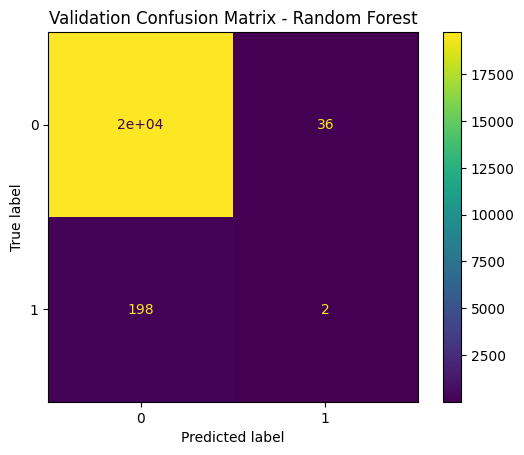

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Validation Confusion Matrix - Random Forest")
plt.show()

In [ ]:
print("Number of predicted class 1s on validation:", (rf_predictions == 1).sum())
print("Number of actual class 1s on validation:", (y_val == 1).sum())

Number of predicted class 1s on validation: 38
Number of actual class 1s on validation: 200


Random Forest now uses the same untouched validation split as the other supervised models. It is trained on SMOTE-balanced training data and compared on validation data before any threshold or hyperparameter decisions are carried into the test set.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=623,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train_smote, y_train_smote)

rf_predictions = rf_model.predict(X_val)

from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_val, rf_predictions)
print("Tuned Random Forest validation accuracy:", rf_accuracy)
print()
print("Validation classification report:")
print(classification_report(y_val, rf_predictions, zero_division=0))

Tuned Random Forest validation accuracy: 0.98695

Validation classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.04      0.01      0.02       200

    accuracy                           0.99     20000
   macro avg       0.52      0.51      0.51     20000
weighted avg       0.98      0.99      0.98     20000



In [ ]:
# Random Forest probabilities + threshold tuning on validation data
rf_prob = rf_model.predict_proba(X_val)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

rf_threshold_results = []

for t in [0.20, 0.10, 0.05, 0.02, 0.01]:
    rf_pred_t = (rf_prob >= t).astype(int)

    rf_threshold_results.append({
        "Threshold": t,
        "Fraud Precision": precision_score(y_val, rf_pred_t, zero_division=0),
        "Fraud Recall": recall_score(y_val, rf_pred_t, zero_division=0),
        "Fraud F1": f1_score(y_val, rf_pred_t, zero_division=0)
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)
rf_threshold_df

,Threshold,Fraud Precision,Fraud Recall,Fraud F1
0,0.20,0.009097,0.065,0.015961
1,0.10,0.009731,0.230,0.018673
2,0.05,0.011115,0.540,0.021781
3,0.02,0.010494,0.840,0.020729
4,0.01,0.010313,0.965,0.020407


In [ ]:
print("Validation probability stats")
print("Min prob:", rf_prob.min())
print("Max prob:", rf_prob.max())
print("Mean prob:", rf_prob.mean())

best_rf_threshold = rf_threshold_df.loc[rf_threshold_df['Fraud F1'].idxmax(), 'Threshold']
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_prob >= best_rf_threshold).astype(int)

print()
print("Chosen validation threshold:", best_rf_threshold)
print("Final test confusion matrix:")
print(confusion_matrix(y_test, rf_test_pred))
print(classification_report(y_test, rf_test_pred, zero_division=0))

Validation probability stats
Min prob: 0.0
Max prob: 0.868440353500035
Mean prob: 0.07457512413185705

Chosen validation threshold: 0.05
Final test confusion matrix:
[[10146  9654]
 [  105    95]]
              precision    recall  f1-score   support

           0       0.99      0.51      0.68     19800
           1       0.01      0.47      0.02       200

    accuracy                           0.51     20000
   macro avg       0.50      0.49      0.35     20000
weighted avg       0.98      0.51      0.67     20000



In [ ]:
# Add model labels
logit_compare = threshold_df.copy()
logit_compare["Model"] = "Logistic Regression"

rf_compare = rf_threshold_df.copy()
rf_compare["Model"] = "Random Forest"

# Combine results
comparison_df = pd.concat([logit_compare, rf_compare], ignore_index=True)

# Reorder columns for readability
comparison_df = comparison_df[
    ["Model", "Threshold", "Fraud Precision", "Fraud Recall", "Fraud F1"]
]

comparison_df.sort_values(["Model", "Threshold"], ascending=[True, False])

,Model,Threshold,Fraud Precision,Fraud Recall,Fraud F1
0,Logistic Regression,0.50,0.010918,0.535,0.021400
1,Logistic Regression,0.30,0.010000,1.000,0.019802
2,Logistic Regression,0.20,0.010000,1.000,0.019802
3,Logistic Regression,0.10,0.010000,1.000,0.019802
4,Random Forest,0.20,0.009097,0.065,0.015961
5,Random Forest,0.10,0.009731,0.230,0.018673
6,Random Forest,0.05,0.011115,0.540,0.021781
7,Random Forest,0.02,0.010494,0.840,0.020729
8,Random Forest,0.01,0.010313,0.965,0.020407


## Model Comparison Notes

Logistic Regression and Random Forest are now compared using validation-set threshold tables, which makes the comparison much more defensible. Final test-set results should be reported only after the threshold is selected on validation data.

# kth Nearest Neighbour

In [ ]:
# ============================================================
#  K-Nearest Neighbors (Credit Card Fraud Detection)
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Scale with train-only fit
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train)
X_val_knn = scaler_knn.transform(X_val)
X_test_knn = scaler_knn.transform(X_test)

# Step 2: Apply SMOTE to the training split only
smote_knn = SMOTE(random_state=42)
X_train_knn_res, y_train_knn_res = smote_knn.fit_resample(X_train_knn, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_knn_res).value_counts())

Class distribution after SMOTE:
IsFraud
0    59400
1    59400
Name: count, dtype: int64


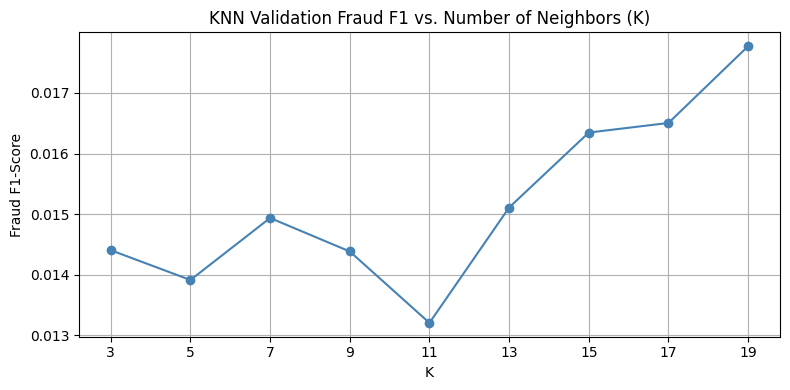

Best K on validation: 19  |  Best Fraud F1: 0.0178


In [ ]:
# Step 3: Find optimal K using validation F1
k_range = range(3, 20, 2)
f1_scores_k = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn_temp.fit(X_train_knn_res, y_train_knn_res)
    y_pred_temp = knn_temp.predict(X_val_knn)
    f1_scores_k.append(f1_score(y_val, y_pred_temp, zero_division=0))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), f1_scores_k, marker='o', color='steelblue')
plt.title('KNN Validation Fraud F1 vs. Number of Neighbors (K)')
plt.xlabel('K')
plt.ylabel('Fraud F1-Score')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = list(k_range)[f1_scores_k.index(max(f1_scores_k))]
print(f"Best K on validation: {best_k}  |  Best Fraud F1: {max(f1_scores_k):.4f}")

In [ ]:
# Step 4: Train final KNN model with best K
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance',
    n_jobs=-1
)
knn_model.fit(X_train_knn_res, y_train_knn_res)

KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=19,
                     weights='distance')

In [ ]:
# Step 5: Validation predictions and evaluation
y_pred_knn = knn_model.predict(X_val_knn)
y_prob_knn = knn_model.predict_proba(X_val_knn)[:, 1]

print("=== KNN Validation Results (Default Threshold = 0.5) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_knn))
print()
print("Classification Report:")
print(classification_report(y_val, y_pred_knn, zero_division=0))
print("Validation ROC AUC:", roc_auc_score(y_val, y_prob_knn))

=== KNN Validation Results (Default Threshold = 0.5) ===
Accuracy: 0.8097

Confusion Matrix:
[[16161  3639]
 [  167    33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.89     19800
           1       0.01      0.17      0.02       200

    accuracy                           0.81     20000
   macro avg       0.50      0.49      0.46     20000
weighted avg       0.98      0.81      0.89     20000

Validation ROC AUC: 0.4875978535353536


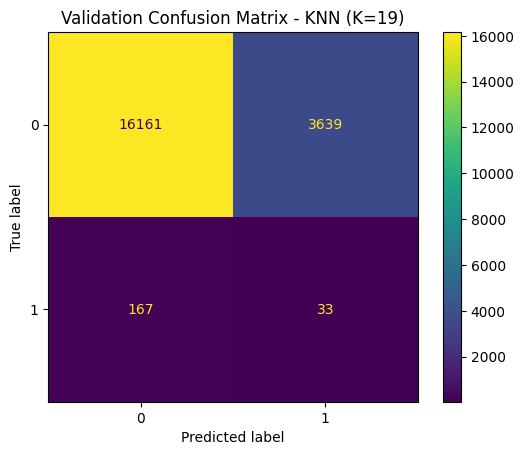

In [ ]:
# Step 6: Validation confusion matrix plot
cm_knn = confusion_matrix(y_val, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title(f"Validation Confusion Matrix - KNN (K={best_k})")
plt.show()

In [ ]:
# Step 7: Threshold tuning on validation data
knn_threshold_results = []

for t in [0.50, 0.30, 0.20, 0.10]:
    y_pred_t = (y_prob_knn >= t).astype(int)
    knn_threshold_results.append({
        "Threshold": t,
        "Fraud Precision": precision_score(y_val, y_pred_t, zero_division=0),
        "Fraud Recall": recall_score(y_val, y_pred_t, zero_division=0),
        "Fraud F1": f1_score(y_val, y_pred_t, zero_division=0)
    })

knn_threshold_df = pd.DataFrame(knn_threshold_results)
print("=== KNN Validation Threshold Sensitivity ===")
print(knn_threshold_df.to_string(index=False))

best_knn_threshold = knn_threshold_df.loc[knn_threshold_df['Fraud F1'].idxmax(), 'Threshold']
print()
print("Chosen validation threshold:", best_knn_threshold)

=== KNN Validation Threshold Sensitivity ===
 Threshold  Fraud Precision  Fraud Recall  Fraud F1
       0.5         0.008987         0.165  0.017045
       0.3         0.009383         0.245  0.018075
       0.2         0.009298         0.280  0.017998
       0.1         0.009506         0.325  0.018471

Chosen validation threshold: 0.1


=== KNN Final Test Results ===
Accuracy: 0.6522

Confusion Matrix:
[[12969  6831]
 [  125    75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     19800
           1       0.01      0.38      0.02       200

    accuracy                           0.65     20000
   macro avg       0.50      0.52      0.40     20000
weighted avg       0.98      0.65      0.78     20000

Test ROC AUC: 0.5080607323232323


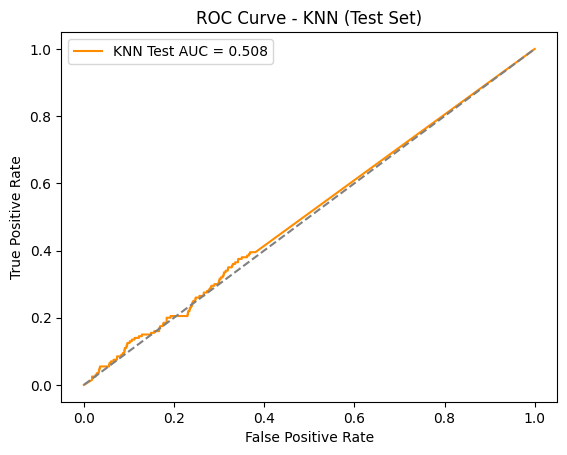

In [ ]:
# Step 8: Final test evaluation
y_prob_knn_test = knn_model.predict_proba(X_test_knn)[:, 1]
y_pred_knn_test = (y_prob_knn_test >= best_knn_threshold).astype(int)

print("=== KNN Final Test Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_test))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_test))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_knn_test, zero_division=0))
print("Test ROC AUC:", roc_auc_score(y_test, y_prob_knn_test))

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn_test)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"KNN Test AUC = {roc_auc_knn:.3f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN (Test Set)")
plt.legend()
plt.show()

### KNN Notes

KNN now follows the same pattern as the other supervised models: train-only scaling, SMOTE only on the training split, K selected on validation data, threshold selected on validation data, and one final evaluation on the untouched test set.

# Autoencoder

In [ ]:
# ============================================================
#  AUTOENCODER - Anomaly Detection for Credit Card Fraud
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
    roc_curve, auc, precision_score,
    recall_score, f1_score
)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Step 1: Scale features with train-only fit
scaler_ae = StandardScaler()
X_train_ae = scaler_ae.fit_transform(X_train)
X_val_ae = scaler_ae.transform(X_val)
X_test_ae = scaler_ae.transform(X_test)

# Step 2: Train ONLY on non-fraud transactions from the training split
X_train_normal = X_train_ae[y_train == 0]
X_val_normal = X_val_ae[y_val == 0]

print(f"Training autoencoder on {X_train_normal.shape[0]} normal transactions only")
print(f"Validation normal examples: {X_val_normal.shape[0]}")
print(f"Input feature dimensions: {X_train_normal.shape[1]}")

Training autoencoder on 59400 normal transactions only
Validation normal examples: 19800
Input feature dimensions: 17


In [ ]:
# ── Step 3: Build the Autoencoder architecture ──
input_dim = X_train_normal.shape[1]

# Encoder compresses input → bottleneck
# Decoder reconstructs input from bottleneck
# Fraud will have HIGH reconstruction error (it looks different from normal)

inputs   = Input(shape=(input_dim,))
encoded  = Dense(32, activation='relu')(inputs)
encoded  = Dense(16, activation='relu')(encoded)
bottleneck = Dense(8, activation='relu')(encoded)   # compressed representation
decoded  = Dense(16, activation='relu')(bottleneck)
decoded  = Dense(32, activation='relu')(decoded)
outputs  = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,489 (9.72 KB)

 Trainable params: 2,489 (9.72 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 4: Train the autoencoder with explicit validation data
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_normal, X_val_normal),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6917 - val_loss: 0.4129
Epoch 2/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3259 - val_loss: 0.2784
Epoch 3/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2418 - val_loss: 0.2085
Epoch 4/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1789 - val_loss: 0.1599
Epoch 5/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1495 - val_loss: 0.1397
Epoch 6/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1224 - val_loss: 0.1125
Epoch 7/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0990 - val_loss: 0.0933
Epoch 8/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0843 - val_loss: 0.0828
Epoch 9/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0770 - val_loss: 0.0765
Epoch 10/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0729 - val_loss: 0.0729
Epoch 11/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0707 - val_loss: 0.0710
Epoch 12/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

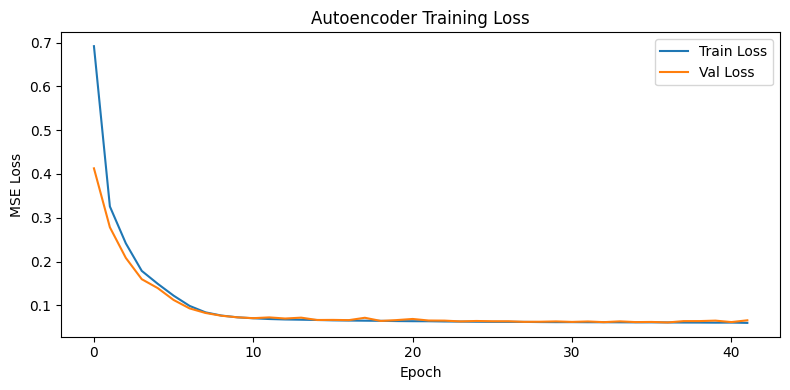

In [ ]:
# ── Step 5: Plot training loss curve ──
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Compute reconstruction error on validation set
X_val_reconstructed = autoencoder.predict(X_val_ae)
reconstruction_errors = np.mean(np.square(X_val_ae - X_val_reconstructed), axis=1)

print("Validation Reconstruction Error Stats:")
print(f"  Min:    {reconstruction_errors.min():.6f}")
print(f"  Max:    {reconstruction_errors.max():.6f}")
print(f"  Mean:   {reconstruction_errors.mean():.6f}")
print(f"  Median: {np.median(reconstruction_errors):.6f}")

errors_nonfraud = reconstruction_errors[y_val == 0]
errors_fraud = reconstruction_errors[y_val == 1]

print()
print(f"Mean error - Non-Fraud: {errors_nonfraud.mean():.6f}")
print(f"Mean error - Fraud:     {errors_fraud.mean():.6f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Validation Reconstruction Error Stats:
  Min:    0.000435
  Max:    0.483406
  Mean:   0.061278
  Median: 0.035155

Mean error - Non-Fraud: 0.061212
Mean error - Fraud:     0.067770


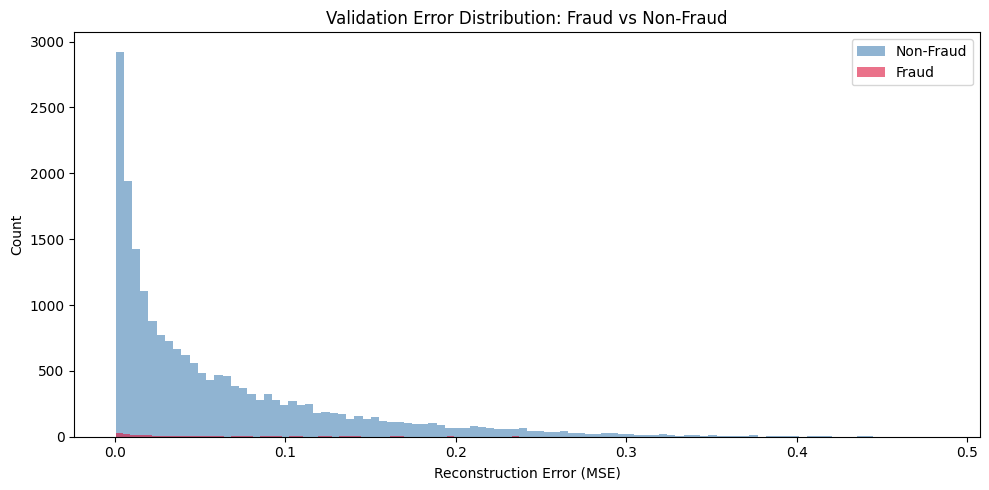

In [ ]:
# Step 7: Plot validation reconstruction error distribution
plt.figure(figsize=(10, 5))
plt.hist(errors_nonfraud, bins=100, alpha=0.6, label='Non-Fraud', color='steelblue')
plt.hist(errors_fraud, bins=100, alpha=0.6, label='Fraud', color='crimson')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Validation Error Distribution: Fraud vs Non-Fraud')
plt.legend()
plt.tight_layout()
plt.show()

Validation ROC AUC (Autoencoder): 0.5131


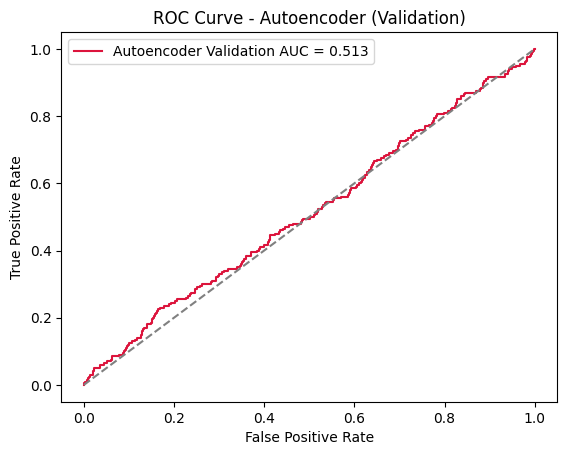

In [ ]:
# Step 8: Validation ROC AUC using reconstruction error as fraud score
roc_auc_ae = roc_auc_score(y_val, reconstruction_errors)
print(f"Validation ROC AUC (Autoencoder): {roc_auc_ae:.4f}")

fpr_ae, tpr_ae, thresholds_ae = roc_curve(y_val, reconstruction_errors)

plt.figure()
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder Validation AUC = {roc_auc_ae:.3f}", color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Autoencoder (Validation)")
plt.legend()
plt.show()

In [ ]:
# Step 9: Threshold tuning using validation reconstruction error
X_train_normal_reconstructed = autoencoder.predict(X_train_normal)
train_normal_errors = np.mean(np.square(X_train_normal - X_train_normal_reconstructed), axis=1)

ae_threshold_results = []

for percentile in [90, 93, 95, 97, 99]:
    threshold = np.percentile(train_normal_errors, percentile)
    y_pred_ae = (reconstruction_errors >= threshold).astype(int)

    ae_threshold_results.append({
        "Percentile Threshold": f"p{percentile}",
        "Error Cutoff": round(threshold, 6),
        "Fraud Precision": precision_score(y_val, y_pred_ae, zero_division=0),
        "Fraud Recall": recall_score(y_val, y_pred_ae, zero_division=0),
        "Fraud F1": f1_score(y_val, y_pred_ae, zero_division=0)
    })

ae_threshold_df = pd.DataFrame(ae_threshold_results)
print("=== Autoencoder Validation Threshold Sensitivity ===")
print(ae_threshold_df.to_string(index=False))

1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
=== Autoencoder Validation Threshold Sensitivity ===
Percentile Threshold  Error Cutoff  Fraud Precision  Fraud Recall  Fraud F1
                 p90      0.160006         0.012054         0.120  0.021908
                 p93      0.185269         0.011888         0.085  0.020859
                 p95      0.207749         0.013084         0.070  0.022047
                 p97      0.241200         0.016420         0.050  0.024722
                 p99      0.304017         0.019512         0.020  0.019753



Best Validation Threshold: p97  (cutoff=0.2412)
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

=== Autoencoder Final Test Evaluation ===
Confusion Matrix:
[[19211   589]
 [  192     8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     19800
           1       0.01      0.04      0.02       200

    accuracy                           0.96     20000
   macro avg       0.50      0.51      0.50     20000
weighted avg       0.98      0.96      0.97     20000

Test ROC AUC: 0.5122391414141414


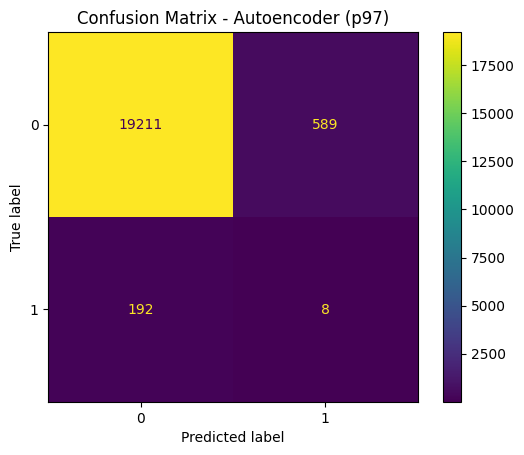

In [ ]:
# Step 10: Final test evaluation with threshold chosen on validation
best_row = ae_threshold_df.loc[ae_threshold_df['Fraud F1'].idxmax()]
print()
print(f"Best Validation Threshold: {best_row['Percentile Threshold']}  (cutoff={best_row['Error Cutoff']})")

best_percentile = int(best_row['Percentile Threshold'].replace('p', ''))
best_cutoff = np.percentile(train_normal_errors, best_percentile)

X_test_reconstructed = autoencoder.predict(X_test_ae)
reconstruction_errors_test = np.mean(np.square(X_test_ae - X_test_reconstructed), axis=1)
y_pred_best_ae = (reconstruction_errors_test >= best_cutoff).astype(int)

print()
print("=== Autoencoder Final Test Evaluation ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_ae))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best_ae, zero_division=0))
print("Test ROC AUC:", roc_auc_score(y_test, reconstruction_errors_test))

cm_ae = confusion_matrix(y_test, y_pred_best_ae)
ConfusionMatrixDisplay(confusion_matrix=cm_ae).plot()
plt.title(f"Confusion Matrix - Autoencoder ({best_row['Percentile Threshold']})")
plt.show()

### Autoencoder Note

The autoencoder is the one model in this notebook that should **not** use SMOTE. It is an anomaly-detection approach trained only on normal transactions, with validation used for threshold selection and the test set used once for final evaluation.

## Ensemble Learning

This section adds a soft-voting ensemble using the strongest supervised models in the notebook. Each base model keeps its own preprocessing and SMOTE step inside an `imblearn` pipeline so that resampling happens only during training.

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

log_reg_ens = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

rf_ens = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=623,
        n_jobs=-1
    ))
])

xgb_ens = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42))
])

ensemble_model = VotingClassifier(
    estimators=[
        ("lr", log_reg_ens),
        ("rf", rf_ens),
        ("xgb", xgb_ens),
    ],
    voting="soft"
)

ensemble_model.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('smote', SMOTE(random_state=42)),
                                              ('model',
                                               LogisticRegression(max_iter=1000,
                                                                  random_state=42))])),
                             ('rf',
                              Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                              ('model',
                                               RandomForestClassifier(min_samples_leaf=5,
                                                                      n_estimators=300,
                                                                      n_jobs=-1,
                                                                      random_state=623))])),
                             ('xgb',
                              Pipeline(step...
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=None,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=None,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...))]))],
                 voting='soft')

In [ ]:
# Validation performance at the default threshold
y_val_pred_ens = ensemble_model.predict(X_val)
y_val_prob_ens = ensemble_model.predict_proba(X_val)[:, 1]

print("=== Ensemble Validation Results (Default Threshold = 0.5) ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_ens))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_ens))
print()
print("Classification Report:")
print(classification_report(y_val, y_val_pred_ens, zero_division=0))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_prob_ens))

=== Ensemble Validation Results (Default Threshold = 0.5) ===
Accuracy: 0.9839

Confusion Matrix:
[[19676   124]
 [  198     2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19800
           1       0.02      0.01      0.01       200

    accuracy                           0.98     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.98      0.98     20000

Validation ROC AUC: 0.51265


In [ ]:
# Threshold tuning on validation data
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

ensemble_threshold_results = []

for t in [0.50, 0.30, 0.20, 0.10]:
    y_pred_t = (y_val_prob_ens >= t).astype(int)
    ensemble_threshold_results.append({
        "Threshold": t,
        "Fraud Precision": precision_score(y_val, y_pred_t, zero_division=0),
        "Fraud Recall": recall_score(y_val, y_pred_t, zero_division=0),
        "Fraud F1": f1_score(y_val, y_pred_t, zero_division=0)
    })

ensemble_threshold_df = pd.DataFrame(ensemble_threshold_results)
print("=== Ensemble Validation Threshold Sensitivity ===")
print(ensemble_threshold_df.to_string(index=False))

best_ensemble_threshold = ensemble_threshold_df.loc[ensemble_threshold_df['Fraud F1'].idxmax(), 'Threshold']
print()
print("Chosen validation threshold:", best_ensemble_threshold)

=== Ensemble Validation Threshold Sensitivity ===
 Threshold  Fraud Precision  Fraud Recall  Fraud F1
       0.5         0.015873          0.01  0.012270
       0.3         0.010984          0.11  0.019973
       0.2         0.010786          0.51  0.021125
       0.1         0.010000          1.00  0.019802

Chosen validation threshold: 0.2


In [ ]:
# Final test evaluation using the threshold chosen on validation
y_test_prob_ens = ensemble_model.predict_proba(X_test)[:, 1]
y_test_pred_ens = (y_test_prob_ens >= best_ensemble_threshold).astype(int)

print("=== Ensemble Final Test Results ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred_ens))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_ens))
print()
print("Classification Report:")
print(classification_report(y_test, y_test_pred_ens, zero_division=0))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob_ens))

=== Ensemble Final Test Results ===
Accuracy: 0.52955

Confusion Matrix:
[[10487  9313]
 [   96   104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.53      0.69     19800
           1       0.01      0.52      0.02       200

    accuracy                           0.53     20000
   macro avg       0.50      0.52      0.36     20000
weighted avg       0.98      0.53      0.68     20000

Test ROC AUC: 0.5152121212121212


### Ensemble Notes

This ensemble uses Logistic Regression, Random Forest, and XGBoost because they are the strongest supervised candidates in the current notebook. KNN was left out because its validation performance was much weaker, and the autoencoder was left out because it is an anomaly-detection model rather than a supervised probability model.

If the ensemble improves recall or F1 on the validation and test sets, you can now describe it as completed work in the report instead of future work.

## ROC-AUC Summary Table

This section gathers final test ROC-AUC values for the main models in one place so the comparison is apples to apples.

In [ ]:
y_test_prob = model.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# Ensure each model contributes a final test ROC-AUC value
feature_engineered_test_prob = log_reg.predict_proba(X_test_fe_scaled)[:, 1]
random_forest_test_prob = rf_test_prob
logistic_regression_test_prob = y_test_prob_log
xgboost_test_prob = y_test_prob
knn_test_prob = y_prob_knn_test
autoencoder_test_score = reconstruction_errors_test
ensemble_test_prob = y_test_prob_ens

roc_auc_summary = [
    {
        "Model": "XGBoost",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, xgboost_test_prob)
    },
    {
        "Model": "Logistic Regression",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, logistic_regression_test_prob)
    },
    {
        "Model": "Feature-Engineered Logistic Regression",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, feature_engineered_test_prob)
    },
    {
        "Model": "Random Forest",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, random_forest_test_prob)
    },
    {
        "Model": "KNN",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, knn_test_prob)
    },
    {
        "Model": "Autoencoder",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, autoencoder_test_score)
    },
    {
        "Model": "Soft Voting Ensemble",
        "Evaluation Split": "Test",
        "ROC-AUC": roc_auc_score(y_test, ensemble_test_prob)
    }
]

roc_auc_df = pd.DataFrame(roc_auc_summary)
roc_auc_df["ROC-AUC"] = roc_auc_df["ROC-AUC"].round(4)
roc_auc_df = roc_auc_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("=== Final Test ROC-AUC Summary ===")
roc_auc_df

=== Final Test ROC-AUC Summary ===


,Model,Evaluation Split,ROC-AUC
0,Soft Voting Ensemble,Test,0.5152
1,Autoencoder,Test,0.5122
2,KNN,Test,0.5081
3,Feature-Engineered Logistic Regression,Test,0.5006
4,Random Forest,Test,0.4971
5,Logistic Regression,Test,0.4929
6,XGBoost,Test,0.4791


In [ ]:
# Optional: concise ranking view for the report
roc_auc_report_df = roc_auc_df[["Model", "ROC-AUC"]].copy()
display(roc_auc_report_df)

best_model_row = roc_auc_report_df.iloc[0]
print(f"Best test ROC-AUC in this table: {best_model_row['Model']} ({best_model_row['ROC-AUC']})")

,Model,ROC-AUC
0,Soft Voting Ensemble,0.5152
1,Autoencoder,0.5122
2,KNN,0.5081
3,Feature-Engineered Logistic Regression,0.5006
4,Random Forest,0.4971
5,Logistic Regression,0.4929
6,XGBoost,0.4791


Best test ROC-AUC in this table: Soft Voting Ensemble (0.5152)
